# Multicomponent test

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import lmfit
from lmfit import minimize, Parameters
from astropy.io import fits
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)

from magE.directMethod import directT, run_all
from magE.functions import mergeSpec, gaussian
from magE.plotutils import * 
from magE.constutils import *
from magE.functions import save_catalog

PATH = '/home/benjamin/Documents/analogs/specs/final_spec/'
os.chdir(PATH)
os.getcwd()

'/home/benjamin/Documents/analogs/specs/final_spec'

In [89]:
# read the data
import pandas as pd
galname = 'J0021'
j0021 = pd.read_csv(galname + '.csv')

wave = j0021['wave'].to_numpy()
flux = j0021['flux'].to_numpy() * 1e17
err = j0021['noise'].to_numpy() * 1e17
igal = np.argmax(np.array(galnames) == 'J0021')

class SpecPiece(object):
    
    def __init__(self, name, wavelength, flux, noise):
        self.name = name
        self.wavelength = wavelength
        self.flux = flux
        self.noise = noise

# [NII]6548 + Ha + [NII]6584
select = (wave > 7175) * (wave < 7250)
ha_nii = SpecPiece('ha+nii', wave[select], flux[select], err[select])

# [OIII]5007
select = (wave > 5485) * (wave < 5520)
oiii_hei = SpecPiece('oiii+hei', wave[select], flux[select], err[select])

# [OIII]4959
select = (wave > 5425) * (wave < 5470)
oiii_4959 = SpecPiece('oiii_4959', wave[select], flux[select], err[select])

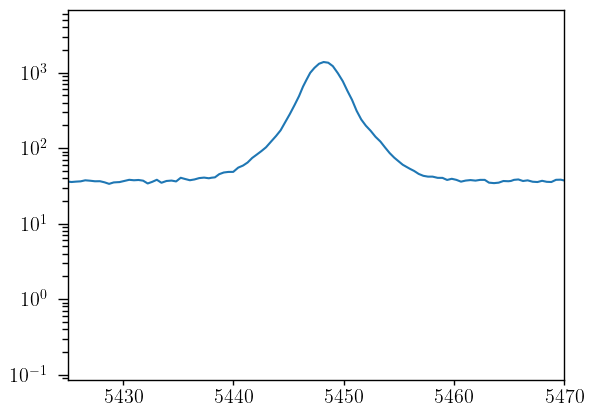

In [90]:
plt.plot(wave, flux)
plt.xlim(5425, 5470)
plt.yscale('log')

# Single gaussian component

## [OIII]4959

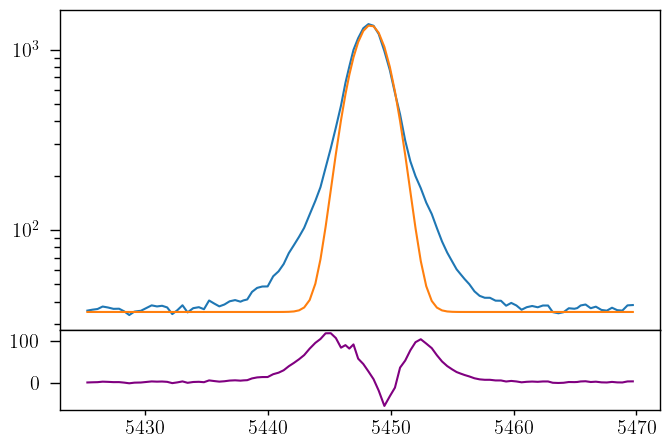

In [91]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 35

oiiib = gaussian(oiii_4959.wavelength, 5000, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.5)

ax.plot(oiii_4959.wavelength, bkg + oiiib)
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib, color='purple')
ax.set_yscale('log')

In [92]:
params_oiii_4959 = Parameters()
params_oiii_4959.add('z', value=z_BN[igal])
params_oiii_4959.add('sigma', value=1.5, min=0.)
params_oiii_4959.add('Oiiib_flux', value=5000, min=0.)
params_oiii_4959.add('bkg', value=35, min=0.)


def residual_oiii_4959(params_oiii_4959, x, data, uncertainty):
    
    z = params_oiii_4959['z']
    sigma = params_oiii_4959['sigma']
    oiiib_flux = params_oiii_4959['Oiiib_flux']
    bkg = params_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_flux, wave_cat['[OIII]4959'], z, sigma)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [93]:
np.random.seed(21)
out_oiii_4959 = minimize(residual_oiii_4959, params_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:15<00:00, 161.09it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 2 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 28.0767755  118.93919174  73.09888894  23.67210309]


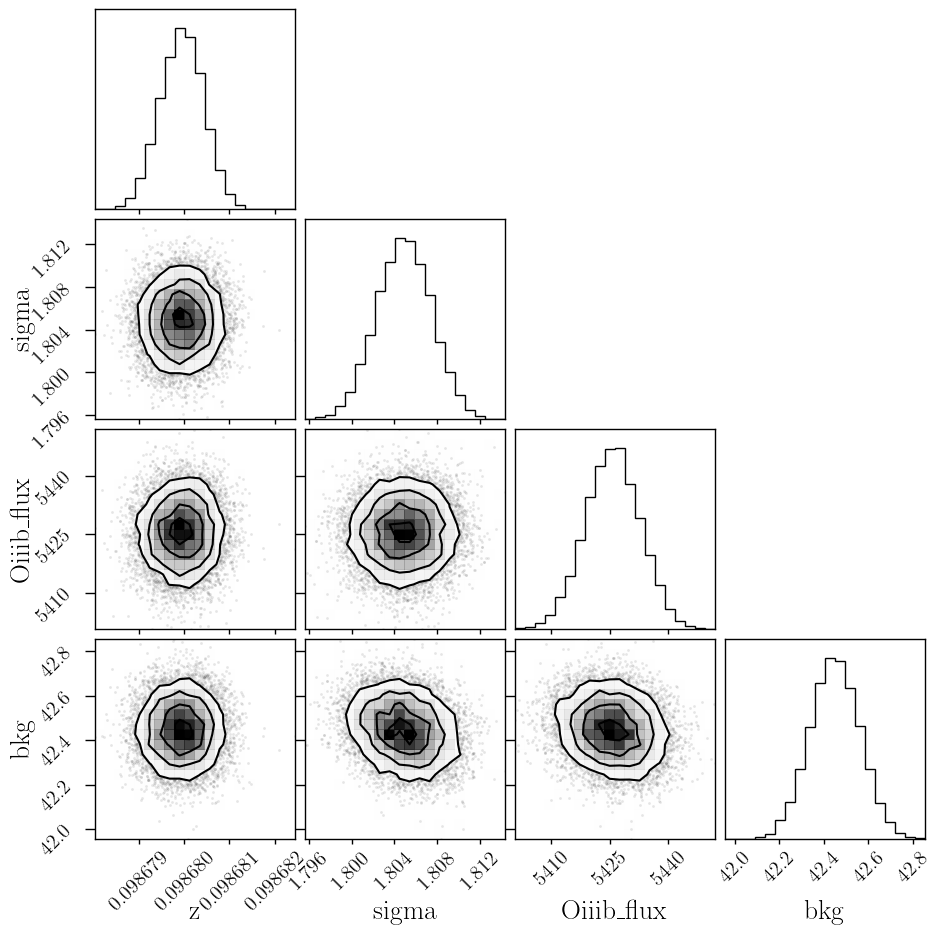

In [94]:
corner.corner(out_oiii_4959.flatchain, labels=out_oiii_4959.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [95]:
out_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z,0.09867995,4.8203e-07,(0.00%),0.0987,-inf,inf,True
sigma,1.80486644,0.00258334,(0.14%),1.5,0.00000000,inf,True
Oiiib_flux,5425.70124,7.03784158,(0.13%),5000,0.00000000,inf,True
bkg,42.4469764,0.11129386,(0.26%),35,0.00000000,inf,True


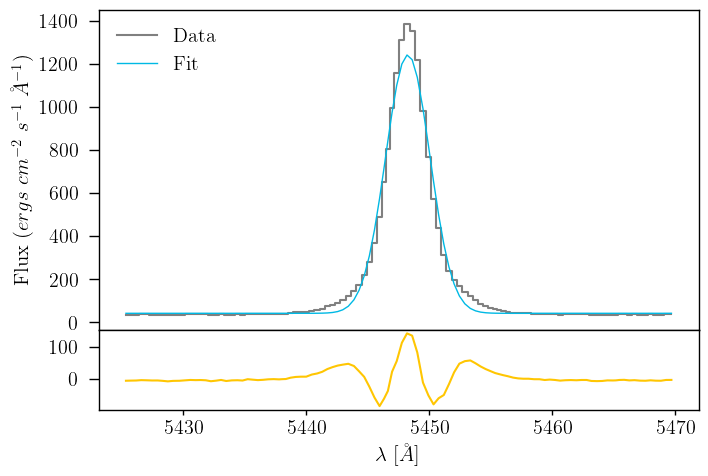

In [96]:
oiiib_flux = out_oiii_4959.flatchain.Oiiib_flux.mean()
oiiib_std = out_oiii_4959.flatchain.Oiiib_flux.std()

bkg_oiii_4959 = out_oiii_4959.flatchain.bkg.mean()
z_oiii_4959 = out_oiii_4959.flatchain.z.mean()
sigma_oiii_4959 = out_oiii_4959.flatchain.sigma.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib = gaussian(oiii_4959.wavelength, oiiib_flux, wave_cat['[OIII]4959'], z_oiii_4959, sigma_oiii_4959)

ax.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [97]:
n_one = len(oiii_4959.flux)
k_one = out_oiii_4959.nvarys
chi_squared_one = out_oiii_4959.chisqr

#log_likelihood_one = np.sum( np.log( np.sqrt((oiii_4959.noise**-2) / (2*np.pi))) - ((oiii_4959.flux - bkg_oiii_4959 - oiiib)**2) / 2 / (oiii_4959.noise**2) ) 
#BIC_one = - (2 * log_likelihood_one) + (k_one * np.log(n_one))

BIC_one = chi_squared_one + (k_one * np.log(n_one))

In [98]:
BIC_one

20449.84718651281

# Double component

## [OIII]4959

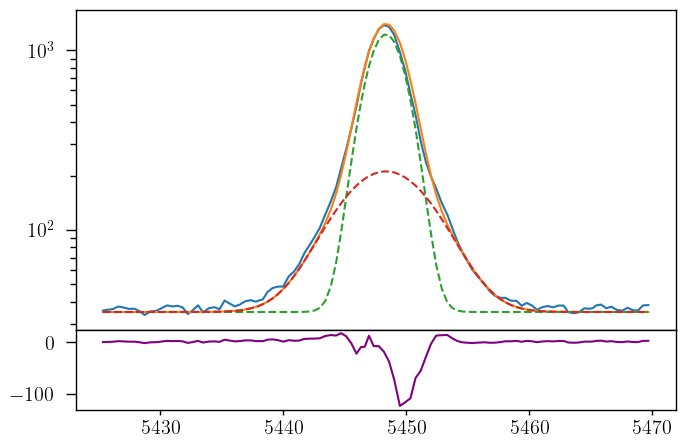

In [99]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 35

oiiib_nar = gaussian(oiii_4959.wavelength, 4500, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.5)
oiiib_brd = gaussian(oiii_4959.wavelength, 1600, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=3.6)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_brd, color='purple')
ax.set_yscale('log')

In [100]:
params2_oiii_4959 = Parameters()
params2_oiii_4959.add('z_nar', value=z_BN[igal])
params2_oiii_4959.add('z_brd', value=z_BN[igal])
params2_oiii_4959.add('sigma_nar', value=1.5, min=0.)
params2_oiii_4959.add('sigma_brd', value=3.6, min=0.)
params2_oiii_4959.add('Oiiib_nar', value=4500, min=0.)
params2_oiii_4959.add('Oiiib_brd', value=1600, min=0.)
params2_oiii_4959.add('bkg', value=35, min=0.)


def residual2_oiii_4959(params2_oiii_4959, x, data, uncertainty):
    
    z_nar = params2_oiii_4959['z_nar']
    z_brd = params2_oiii_4959['z_brd']
    sigma_nar = params2_oiii_4959['sigma_nar']
    sigma_brd = params2_oiii_4959['sigma_brd']
    oiiib_nar = params2_oiii_4959['Oiiib_nar']
    oiiib_brd = params2_oiii_4959['Oiiib_brd']
    bkg = params2_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [101]:
np.random.seed(21)
out2_oiii_4959 = minimize(residual2_oiii_4959, params2_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:19<00:00, 131.09it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 5 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 41.68059019  41.17625741 175.1448863  194.50120325 181.19625962
 195.76036234 173.56267347]


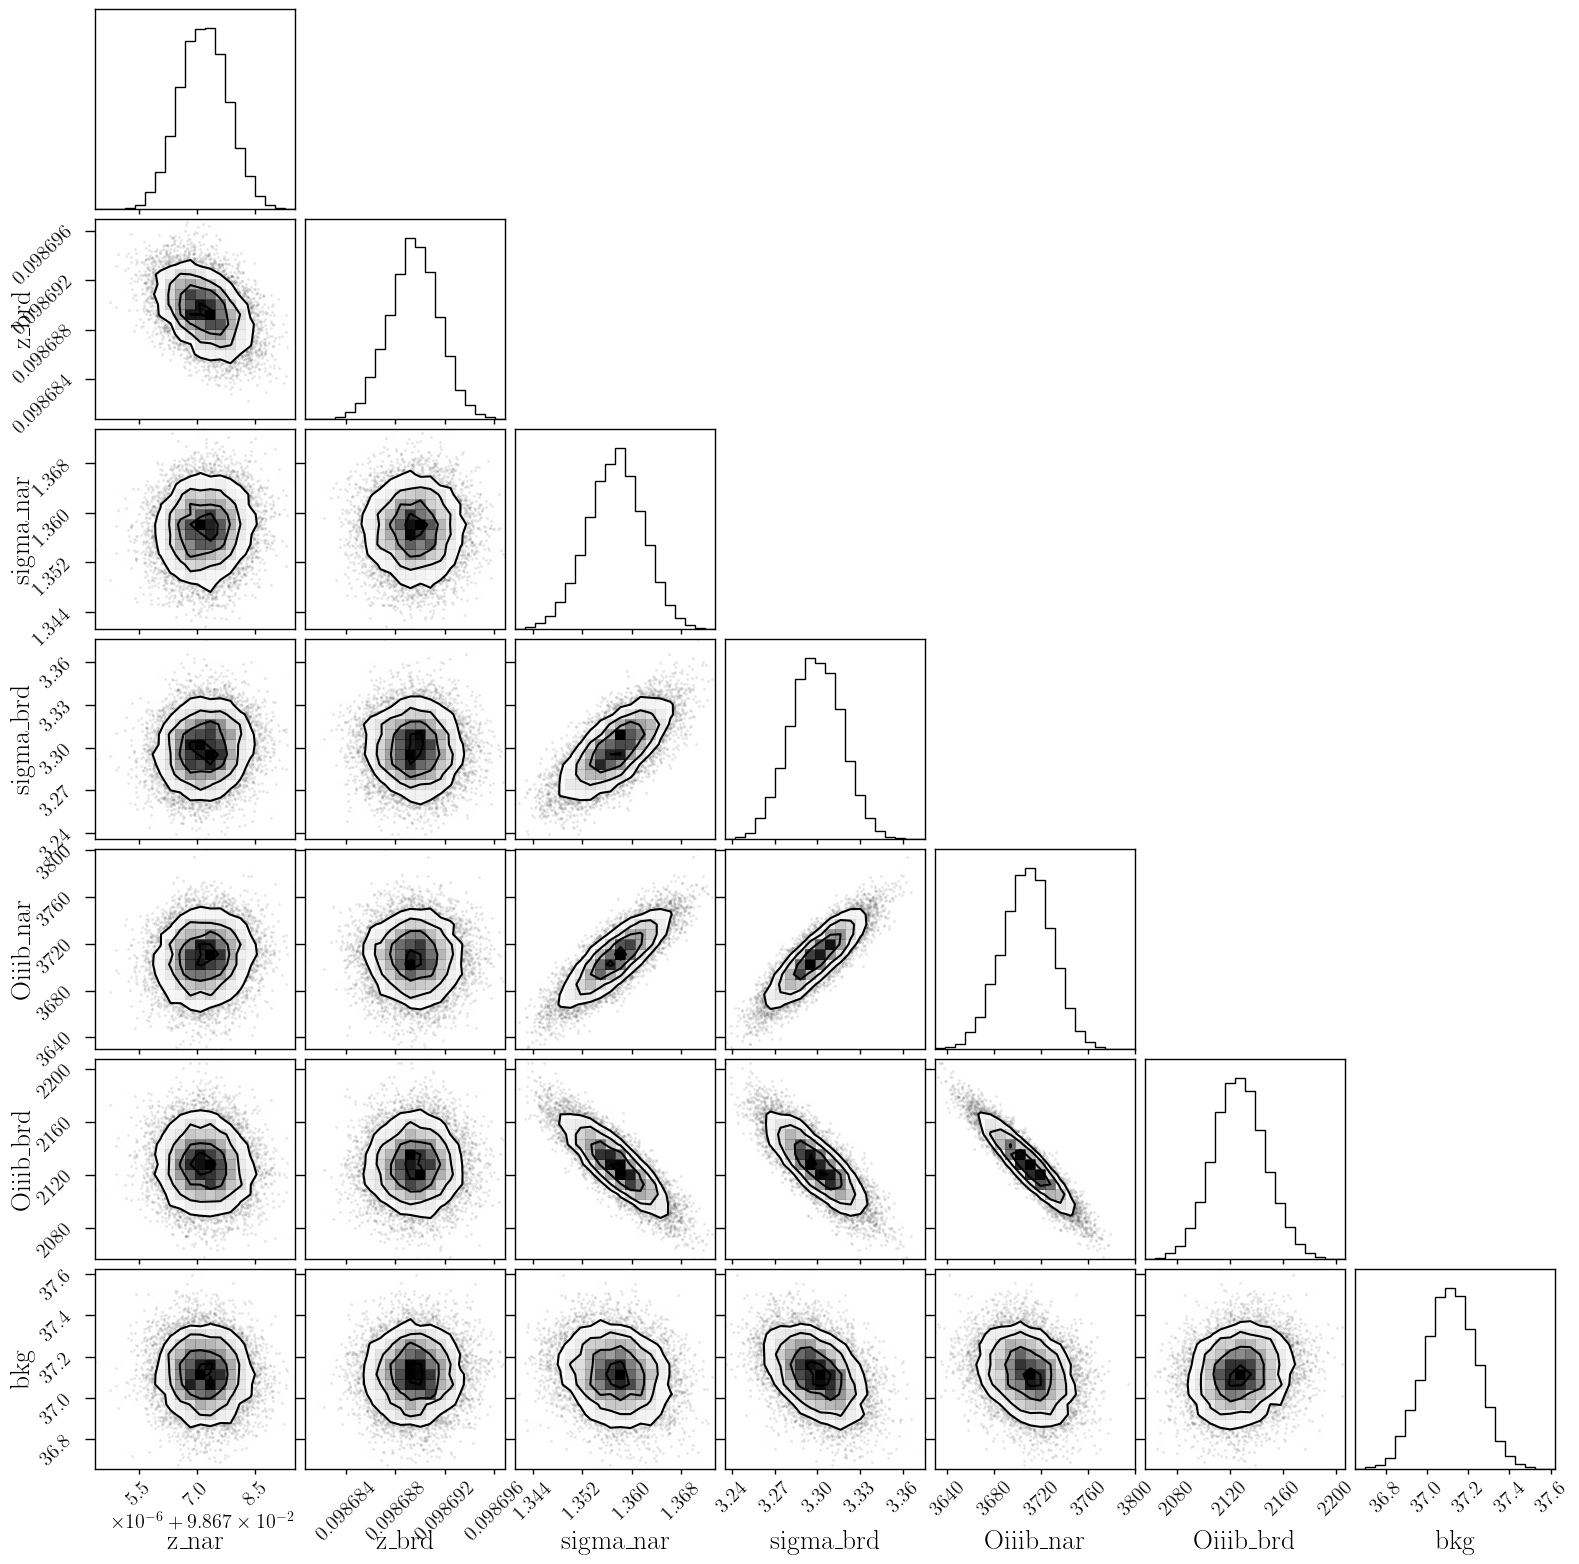

In [102]:
corner.corner(out2_oiii_4959.flatchain, labels=out2_oiii_4959.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [103]:
out2_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.09867719,6.2364e-07,(0.00%),0.0987,-inf,inf,True
z_brd,0.09868957,2.0033e-06,(0.00%),0.0987,-inf,inf,True
sigma_nar,1.35746856,0.00449840,(0.33%),1.5,0.00000000,inf,True
sigma_brd,3.29924412,0.01806772,(0.55%),3.6,0.00000000,inf,True
Oiiib_nar,3708.65001,21.5194503,(0.58%),4500,0.00000000,inf,True
Oiiib_brd,2127.58740,19.6891928,(0.93%),1600,0.00000000,inf,True
bkg,37.1180686,0.12798422,(0.34%),35,0.00000000,inf,True


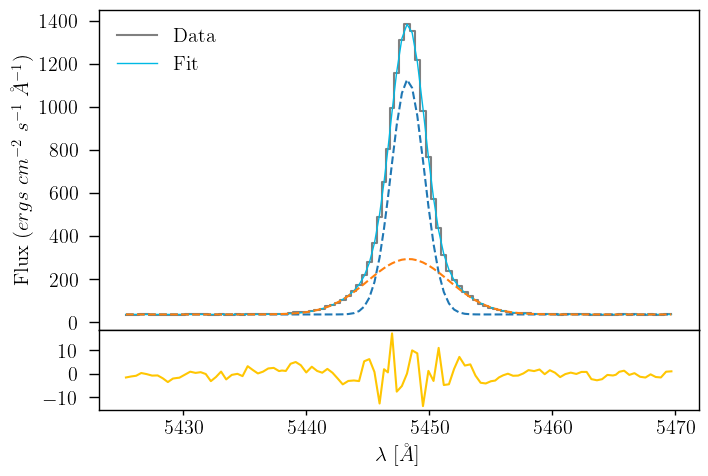

In [104]:
oiiib_nar_flux = out2_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out2_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_brd_flux = out2_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out2_oiii_4959.flatchain.Oiiib_brd.std()

bkg2_oiii_4959 = out2_oiii_4959.flatchain.bkg.mean()

z_nar_oiii_4959 = out2_oiii_4959.flatchain.z_nar.mean()
z_brd_oiii_4959 = out2_oiii_4959.flatchain.z_brd.mean()

sigma_nar_oiii_4959 = out2_oiii_4959.flatchain.sigma_nar.mean()
sigma_brd_oiii_4959 = out2_oiii_4959.flatchain.sigma_brd.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg2_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [105]:
n_two = len(oiii_4959.flux)
k_two = out2_oiii_4959.nvarys
chi_squared_two = out2_oiii_4959.chisqr

#log_likelihood_two = np.sum( np.log( (oiii_4959.noise**-2) / (2*np.pi)) - ((oiii_4959.flux - bkg2_oiii_4959 - oiiib)**2) / 2 / (oiii_4959.noise**2) ) 
#BIC_two = - (2 * log_likelihood_two) + (k_two * np.log(n_two))

BIC_two = chi_squared_two + (k_two * np.log(n_two))

In [106]:
BIC_two

407.51554291914033

# Triple component

## [OIII]4959

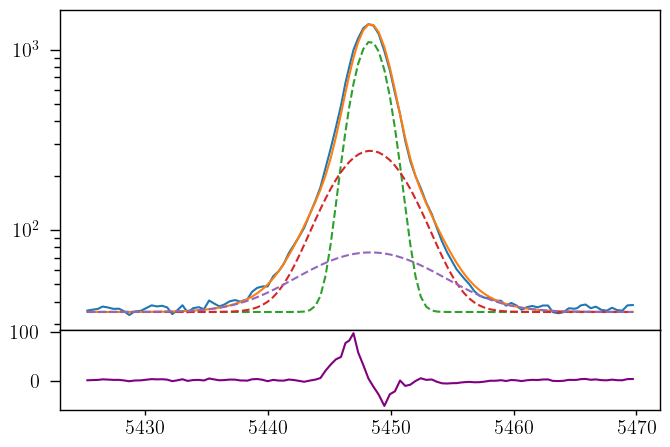

In [107]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 35

oiiib_nar = gaussian(oiii_4959.wavelength, 3500, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.3)
oiiib_mid = gaussian(oiii_4959.wavelength, 1800, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=3)
oiiib_brd = gaussian(oiii_4959.wavelength, 500, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=5)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd + oiiib_mid)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_mid, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_mid - oiiib_brd, color='purple')
ax.set_yscale('log')

In [108]:
params3_oiii_4959 = Parameters()
params3_oiii_4959.add('z_nar', value=z_BN[igal])
params3_oiii_4959.add('z_mid', value=z_BN[igal])
params3_oiii_4959.add('z_brd', value=z_BN[igal])
params3_oiii_4959.add('sigma_nar', value=1.3, min=0.)
params3_oiii_4959.add('sigma_mid', value=3.0, min=0.)
params3_oiii_4959.add('sigma_brd', value=5.0, min=0.)
params3_oiii_4959.add('Oiiib_nar', value=3500, min=0.)
params3_oiii_4959.add('Oiiib_mid', value=1800, min=0.)
params3_oiii_4959.add('Oiiib_brd', value=500, min=0.)
params3_oiii_4959.add('bkg', value=35, min=0.)


def residual3_oiii_4959(params3_oiii_4959, x, data, uncertainty):
    
    z_nar = params3_oiii_4959['z_nar']
    z_mid = params3_oiii_4959['z_mid']
    z_brd = params3_oiii_4959['z_brd']
    
    sigma_nar = params3_oiii_4959['sigma_nar']
    sigma_mid = params3_oiii_4959['sigma_mid']
    sigma_brd = params3_oiii_4959['sigma_brd']
    
    oiiib_nar = params3_oiii_4959['Oiiib_nar']
    oiiib_mid = params3_oiii_4959['Oiiib_mid']
    oiiib_brd = params3_oiii_4959['Oiiib_brd']
    
    bkg = params3_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_mid, wave_cat['[OIII]4959'], z_mid, sigma_mid) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [109]:
np.random.seed(21)
out3_oiii_4959 = minimize(residual3_oiii_4959, params3_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:22<00:00, 110.03it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 10 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [ 52.67218285  83.45709163 153.3659955  116.16584855 117.4371021
 131.98458135 111.58670897 180.08058418 177.23622565 146.71464636]


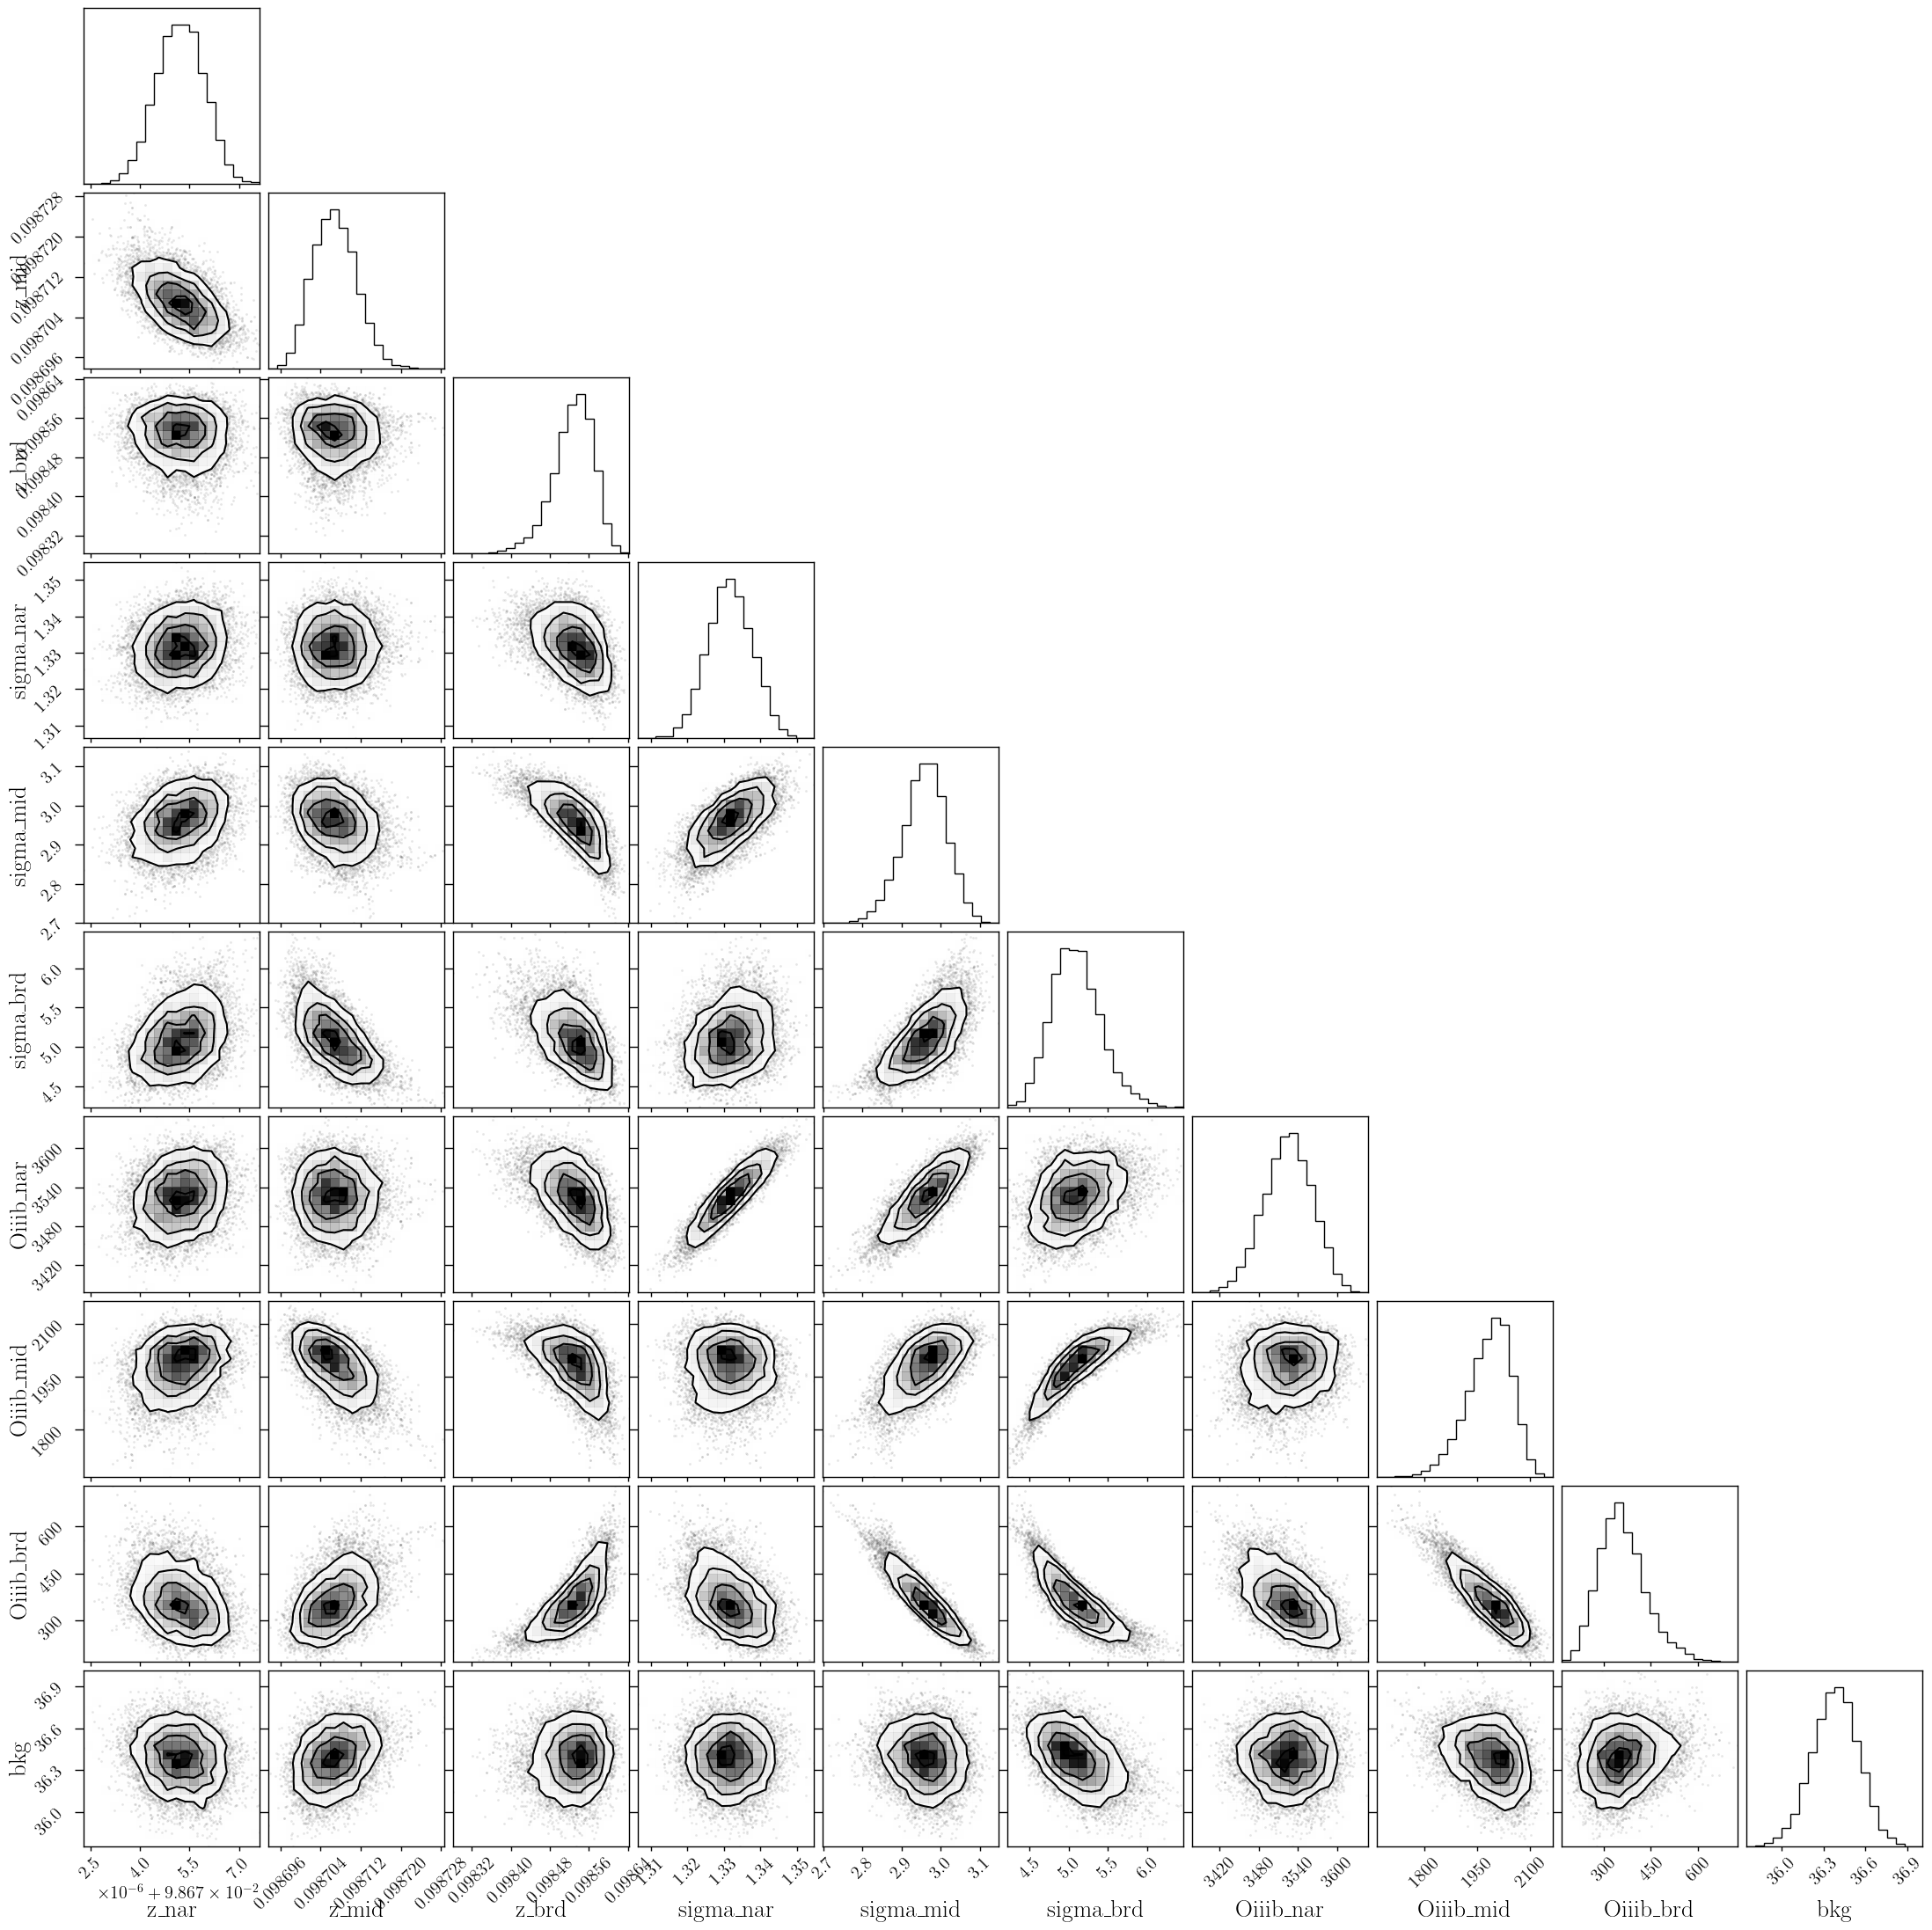

In [110]:
corner.corner(out3_oiii_4959.flatchain, labels=out3_oiii_4959.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [111]:
out3_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.09867524,7.3686e-07,(0.00%),0.0987,-inf,inf,True
z_mid,0.09870682,4.3738e-06,(0.00%),0.0987,-inf,inf,True
z_brd,0.09853161,4.0427e-05,(0.04%),0.0987,-inf,inf,True
sigma_nar,1.33164957,0.00624236,(0.47%),1.3,0.00000000,inf,True
sigma_mid,2.96185431,0.05570713,(1.88%),3.0,0.00000000,inf,True
sigma_brd,5.08255499,0.30761995,(6.05%),5.0,0.00000000,inf,True
Oiiib_nar,3526.40749,37.7819370,(1.07%),3500,0.00000000,inf,True
Oiiib_mid,1990.25377,63.0063003,(3.17%),1800,0.00000000,inf,True
Oiiib_brd,353.853978,73.5781358,(20.79%),500,0.00000000,inf,True
bkg,36.3900709,0.16828068,(0.46%),35,0.00000000,inf,True


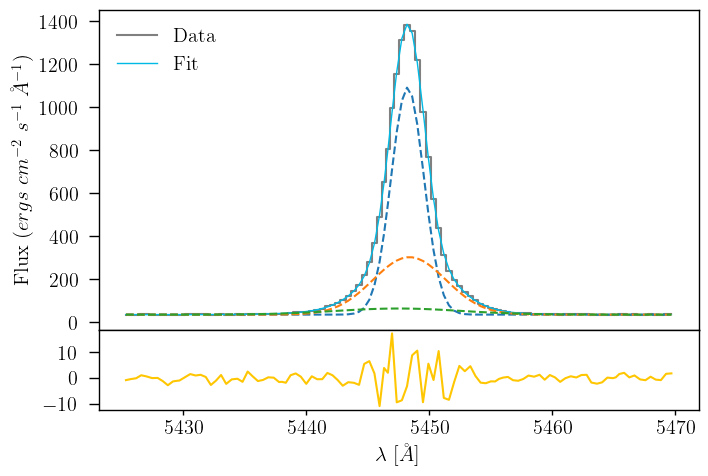

In [112]:
oiiib_nar_flux = out3_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out3_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_mid_flux = out3_oiii_4959.flatchain.Oiiib_mid.mean()
oiiib_mid_std = out3_oiii_4959.flatchain.Oiiib_mid.std()

oiiib_brd_flux = out3_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out3_oiii_4959.flatchain.Oiiib_brd.std()

bkg3_oiii_4959 = out3_oiii_4959.flatchain.bkg.mean()

z_nar_oiii_4959 = out3_oiii_4959.flatchain.z_nar.mean()
z_mid_oiii_4959 = out3_oiii_4959.flatchain.z_mid.mean()
z_brd_oiii_4959 = out3_oiii_4959.flatchain.z_brd.mean()

sigma_nar_oiii_4959 = out3_oiii_4959.flatchain.sigma_nar.mean()
sigma_mid_oiii_4959 = out3_oiii_4959.flatchain.sigma_mid.mean()
sigma_brd_oiii_4959 = out3_oiii_4959.flatchain.sigma_brd.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_mid = gaussian(oiii_4959.wavelength, oiiib_mid_flux, wave_cat['[OIII]4959'], z_mid_oiii_4959, sigma_mid_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_mid + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_mid, ls='--')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg3_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
#ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [113]:
n_three = len(oiii_4959.flux)
k_three = out3_oiii_4959.nvarys
chi_squared_three = out3_oiii_4959.chisqr

#log_likelihood_three = np.sum( np.log( (oiii_4959.noise**-2) / (2*np.pi)) - ((oiii_4959.flux - bkg3_oiii_4959 - oiiib)**2) / 2 / (oiii_4959.noise**2) ) 
#BIC_three = - (2 * log_likelihood_three) + (k_three * np.log(n_three))

BIC_three = chi_squared_three + (k_three * np.log(n_three))

In [114]:
BIC_three

294.418022336617

# Four components

## [OIII]4959

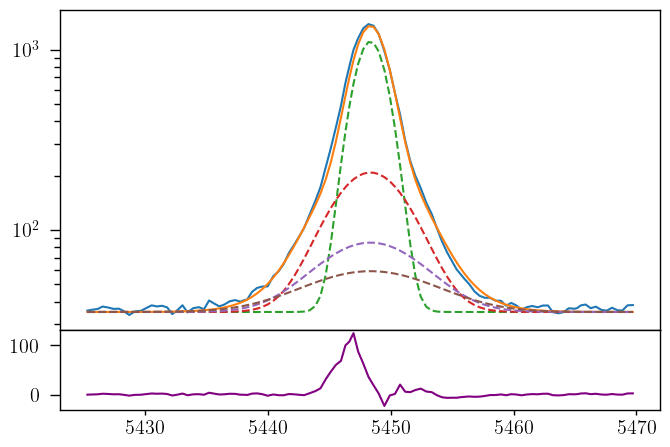

In [115]:
# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.plot(oiii_4959.wavelength, oiii_4959.flux)
bkg = 35

oiiib_nar = gaussian(oiii_4959.wavelength, 3500, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=1.3)
oiiib_mid1 = gaussian(oiii_4959.wavelength, 1300, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=3)
oiiib_mid2 = gaussian(oiii_4959.wavelength, 500, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=4)
oiiib_brd = gaussian(oiii_4959.wavelength, 300, wave_cat['[OIII]4959'], z=z_BN[igal], sigma=5)

ax.plot(oiii_4959.wavelength, bkg + oiiib_nar + oiiib_brd + oiiib_mid1 + oiiib_mid2)
ax.plot(oiii_4959.wavelength, bkg + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_mid1, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_mid2, ls='--')
ax.plot(oiii_4959.wavelength, bkg + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg - oiiib_nar - oiiib_mid1 - oiiib_mid2 - oiiib_brd, color='purple')
ax.set_yscale('log')

In [116]:
params4_oiii_4959 = Parameters()
params4_oiii_4959.add('z_nar', value=z_BN[igal])
params4_oiii_4959.add('z_mid1', value=z_BN[igal])
params4_oiii_4959.add('z_mid2', value=z_BN[igal])
params4_oiii_4959.add('z_brd', value=z_BN[igal])
params4_oiii_4959.add('sigma_nar', value=1.3, min=0.)
params4_oiii_4959.add('sigma_mid1', value=3.0, min=0.)
params4_oiii_4959.add('sigma_mid2', value=4.0, min=0.)
params4_oiii_4959.add('sigma_brd', value=5.0, min=0.)
params4_oiii_4959.add('Oiiib_nar', value=3500, min=0.)
params4_oiii_4959.add('Oiiib_mid1', value=1300, min=0.)
params4_oiii_4959.add('Oiiib_mid2', value=500, min=0.)
params4_oiii_4959.add('Oiiib_brd', value=300, min=0.)
params4_oiii_4959.add('bkg', value=35, min=0.)


def residual4_oiii_4959(params4_oiii_4959, x, data, uncertainty):
    
    z_nar = params4_oiii_4959['z_nar']
    z_mid1 = params4_oiii_4959['z_mid1']
    z_mid2 = params4_oiii_4959['z_mid2']
    z_brd = params4_oiii_4959['z_brd']
    
    sigma_nar = params4_oiii_4959['sigma_nar']
    sigma_mid1 = params4_oiii_4959['sigma_mid1']
    sigma_mid2 = params4_oiii_4959['sigma_mid2']
    sigma_brd = params4_oiii_4959['sigma_brd']
    
    oiiib_nar = params4_oiii_4959['Oiiib_nar']
    oiiib_mid1 = params4_oiii_4959['Oiiib_mid1']
    oiiib_mid2 = params4_oiii_4959['Oiiib_mid2']
    oiiib_brd = params4_oiii_4959['Oiiib_brd']
    
    bkg = params4_oiii_4959['bkg']
    
    x = oiii_4959.wavelength
    model = gaussian(x, oiiib_nar, wave_cat['[OIII]4959'], z_nar, sigma_nar) \
          + gaussian(x, oiiib_mid1, wave_cat['[OIII]4959'], z_mid1, sigma_mid1) \
          + gaussian(x, oiiib_mid2, wave_cat['[OIII]4959'], z_mid2, sigma_mid2) \
          + gaussian(x, oiiib_brd, wave_cat['[OIII]4959'], z_brd, sigma_brd)
    
    return (model + bkg - oiii_4959.flux) / oiii_4959.noise

In [117]:
np.random.seed(21)
out4_oiii_4959 = minimize(residual4_oiii_4959, params4_oiii_4959, args=(1, 1, 1),
                      method='emcee', burn=1500, steps=2500, thin=10)

100%|██████████████████████████████████████| 2500/2500 [00:23<00:00, 105.87it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 13 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 50;
tau: [114.278548   169.94219759 244.5580184  215.06173268  96.5338378
 212.79712246 271.5642768  215.61551515 180.45147508 307.74675749
 280.75057504 250.95395841 169.36921666]


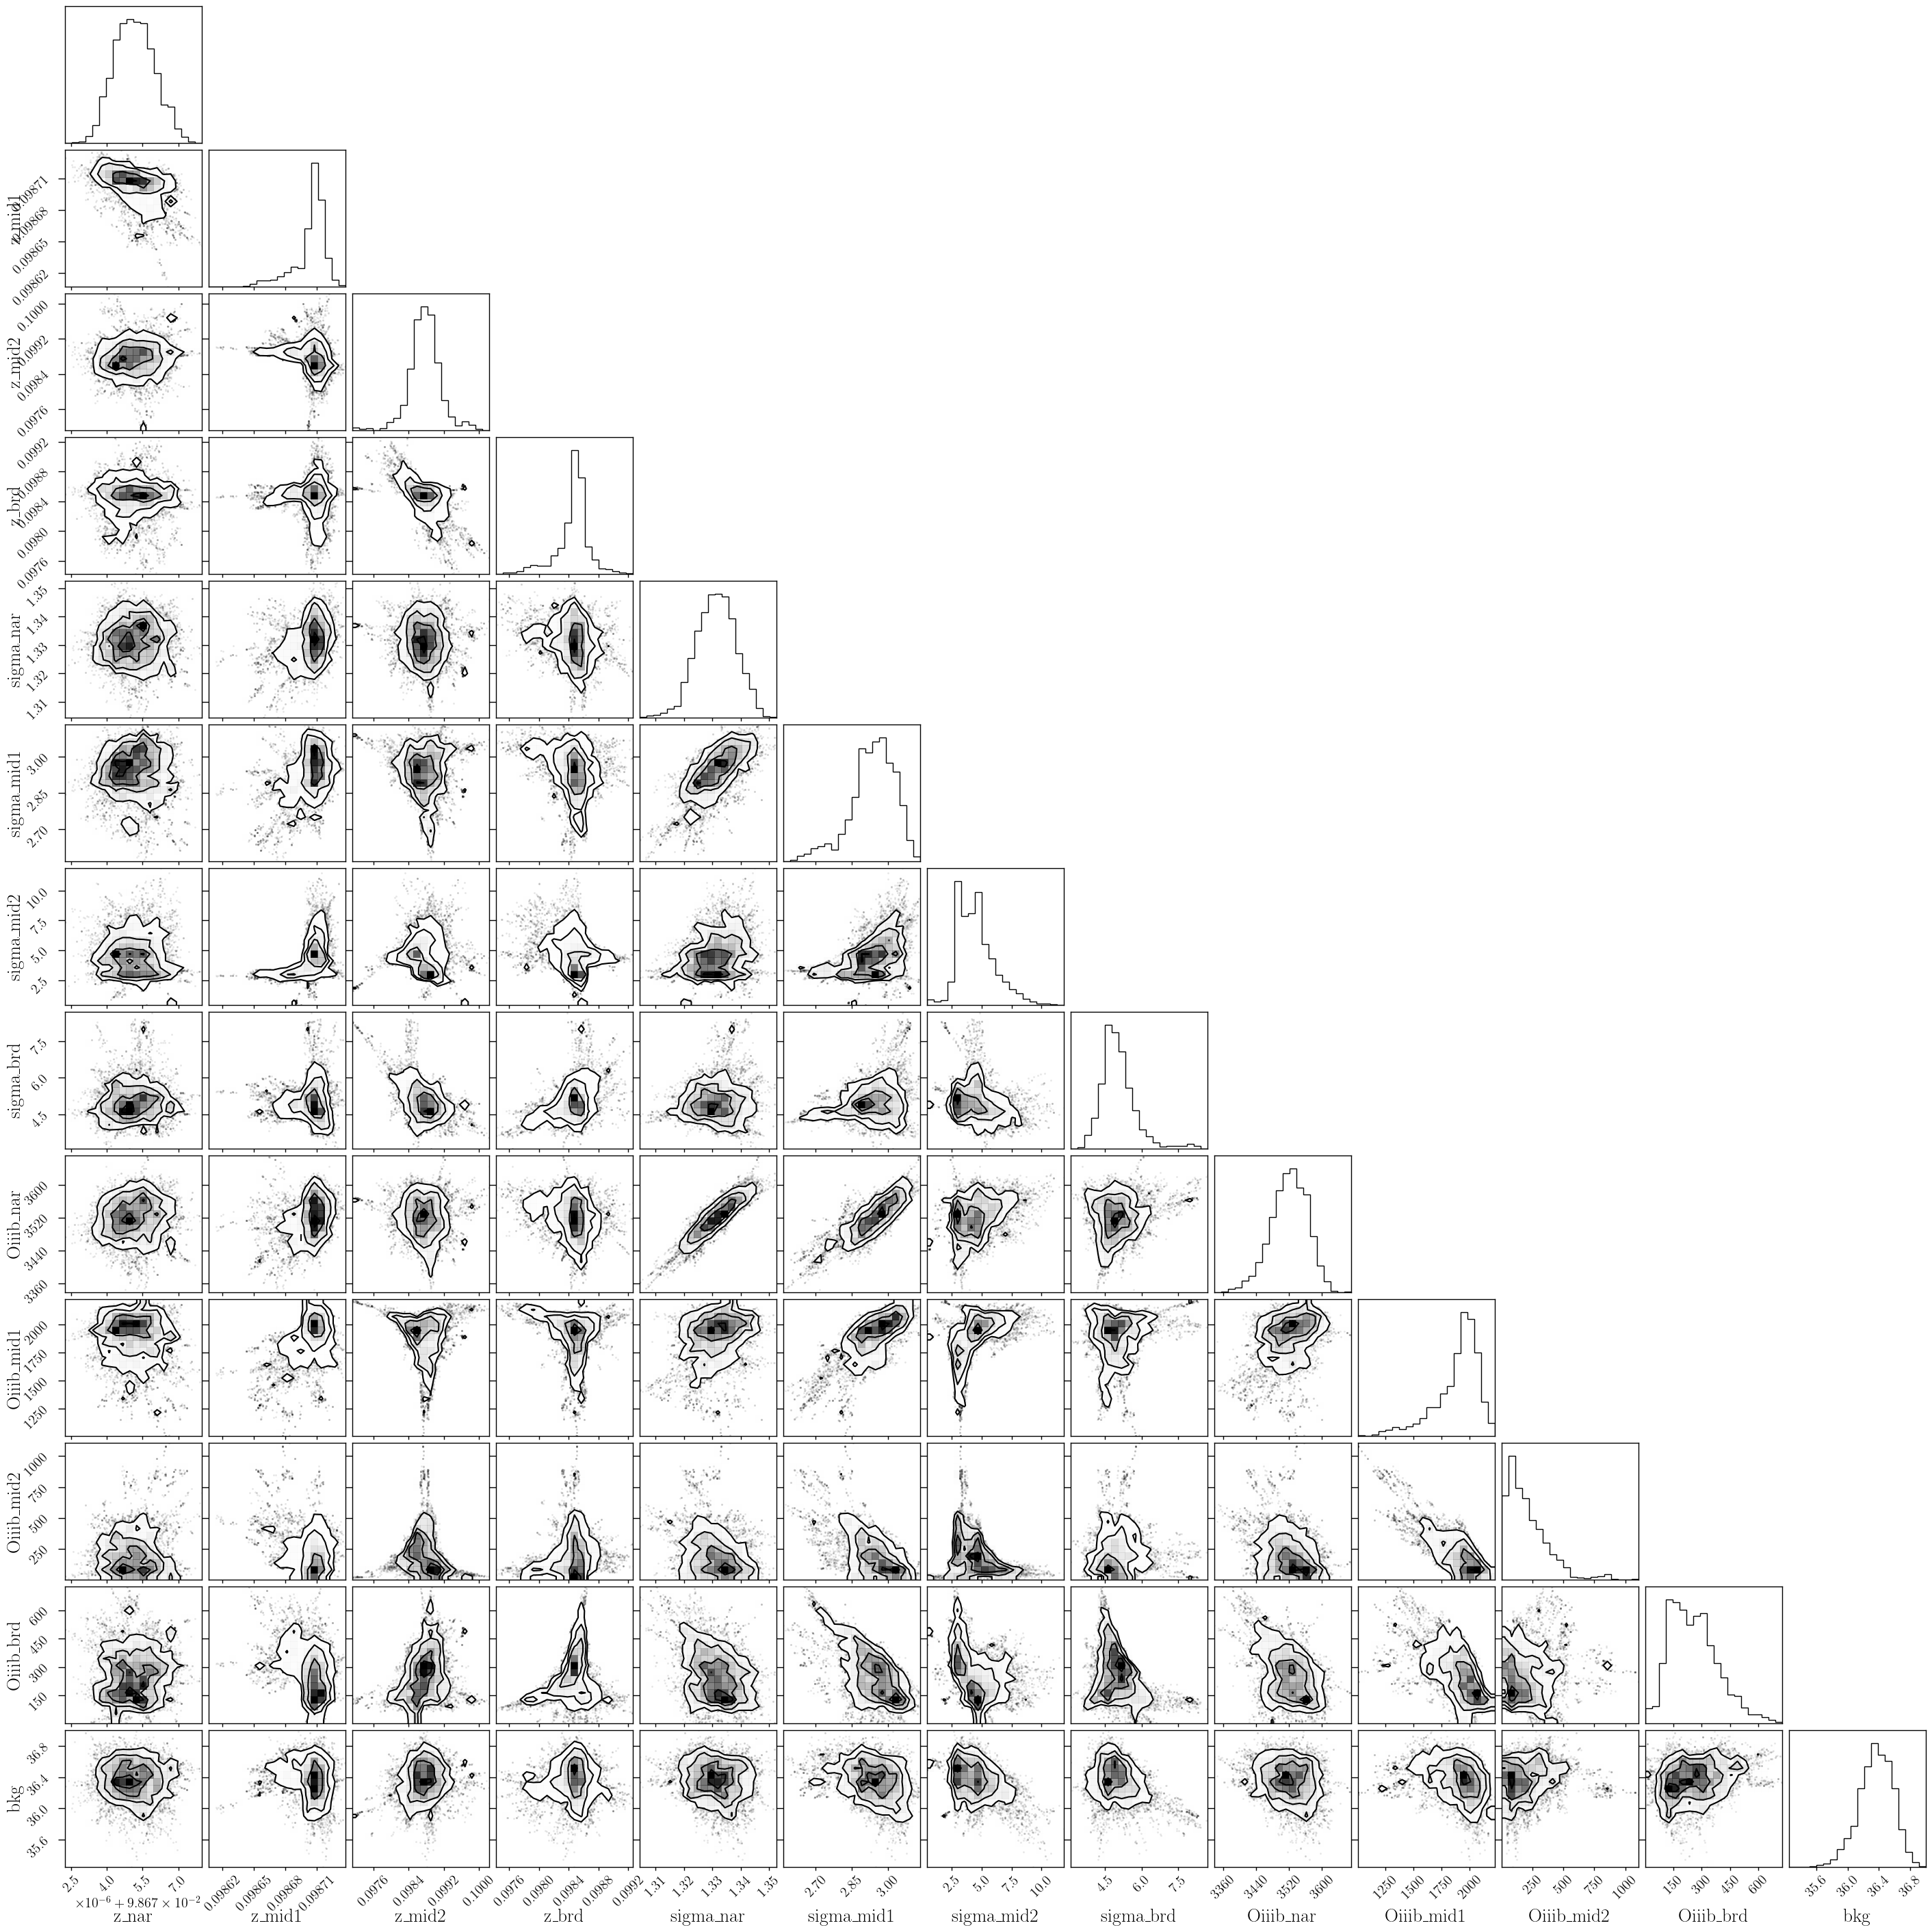

In [118]:
corner.corner(out4_oiii_4959.flatchain, labels=out4_oiii_4959.var_names);
#plt.savefig(fname='corner_ha.jpg', bbox_inches='tight')

In [119]:
out4_oiii_4959.params

name,value,standard error,relative error,initial value,min,max,vary
z_nar,0.09867512,8.4693e-07,(0.00%),0.0987,-inf,inf,True
z_mid1,0.09870739,1.2688e-05,(0.01%),0.0987,-inf,inf,True
z_mid2,0.09875466,2.9973e-04,(0.30%),0.0987,-inf,inf,True
z_brd,0.09848829,1.6089e-04,(0.16%),0.0987,-inf,inf,True
sigma_nar,1.33131401,0.00696088,(0.52%),1.3,0.00000000,inf,True
sigma_mid1,2.94305776,0.08609786,(2.93%),3.0,0.00000000,inf,True
sigma_mid2,4.35434459,1.44781943,(33.25%),4.0,0.00000000,inf,True
sigma_brd,4.91339810,0.58363530,(11.88%),5.0,0.00000000,inf,True
Oiiib_nar,3521.44685,44.5152917,(1.26%),3500,0.00000000,inf,True
Oiiib_mid1,1933.65478,181.361934,(9.38%),1300,0.00000000,inf,True


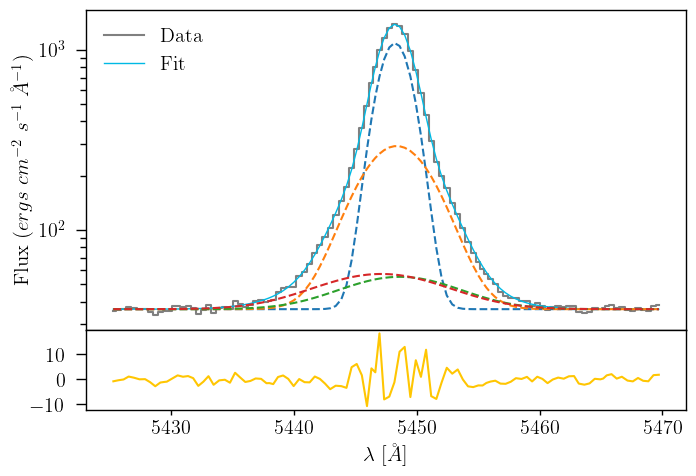

In [120]:
oiiib_nar_flux = out4_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib_nar_std = out4_oiii_4959.flatchain.Oiiib_nar.std()

oiiib_mid1_flux = out4_oiii_4959.flatchain.Oiiib_mid1.mean()
oiiib_mid1_std = out4_oiii_4959.flatchain.Oiiib_mid1.std()

oiiib_mid2_flux = out4_oiii_4959.flatchain.Oiiib_mid2.mean()
oiiib_mid2_std = out4_oiii_4959.flatchain.Oiiib_mid2.std()

oiiib_brd_flux = out4_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib_brd_std = out4_oiii_4959.flatchain.Oiiib_brd.std()

bkg3_oiii_4959 = out4_oiii_4959.flatchain.bkg.mean()

z_nar_oiii_4959 = out4_oiii_4959.flatchain.z_nar.mean()
z_mid1_oiii_4959 = out4_oiii_4959.flatchain.z_mid1.mean()
z_mid2_oiii_4959 = out4_oiii_4959.flatchain.z_mid2.mean()
z_brd_oiii_4959 = out4_oiii_4959.flatchain.z_brd.mean()

sigma_nar_oiii_4959 = out4_oiii_4959.flatchain.sigma_nar.mean()
sigma_mid1_oiii_4959 = out4_oiii_4959.flatchain.sigma_mid1.mean()
sigma_mid2_oiii_4959 = out4_oiii_4959.flatchain.sigma_mid2.mean()
sigma_brd_oiii_4959 = out4_oiii_4959.flatchain.sigma_brd.mean()

# Search for good initial guess

fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))

ax.step(oiii_4959.wavelength, oiii_4959.flux,
            color='gray', label='Data', where='mid')

oiiib_nar = gaussian(oiii_4959.wavelength, oiiib_nar_flux, wave_cat['[OIII]4959'], z_nar_oiii_4959, sigma_nar_oiii_4959)
oiiib_mid1 = gaussian(oiii_4959.wavelength, oiiib_mid1_flux, wave_cat['[OIII]4959'], z_mid1_oiii_4959, sigma_mid1_oiii_4959)
oiiib_mid2 = gaussian(oiii_4959.wavelength, oiiib_mid2_flux, wave_cat['[OIII]4959'], z_mid2_oiii_4959, sigma_mid2_oiii_4959)
oiiib_brd = gaussian(oiii_4959.wavelength, oiiib_brd_flux, wave_cat['[OIII]4959'], z_brd_oiii_4959, sigma_brd_oiii_4959)
oiiib = oiiib_nar + oiiib_mid1 + oiiib_mid2 + oiiib_brd

ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib,
        lw=1, color=c[0], label='Fit')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_nar, ls='--')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_mid1, ls='--')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_mid2, ls='--')
ax.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib_brd, ls='--')
ax1.plot(oiii_4959.wavelength, oiii_4959.flux - bkg3_oiii_4959 - oiiib,
         color=c[3])
ax.set_ylabel(r'Flux ($ergs\ cm^{-2}\  s^{-1}\ \AA^{-1}$)', fontsize=15)
ax1.set_xlabel(r'$\lambda$ [$\AA$]', fontsize=15)
ax.set_yscale('log')
ax.legend(loc='upper left')
#plt.savefig(fname='ha_nii.svg', bbox_inches='tight')

In [121]:
n_four = len(oiii_4959.flux)
k_four = out4_oiii_4959.nvarys
chi_squared_four = out4_oiii_4959.chisqr

#log_likelihood_three = np.sum( np.log( (oiii_4959.noise**-2) / (2*np.pi)) - ((oiii_4959.flux - bkg3_oiii_4959 - oiiib)**2) / 2 / (oiii_4959.noise**2) ) 
#BIC_three = - (2 * log_likelihood_three) + (k_three * np.log(n_three))

BIC_four = chi_squared_four + (k_four * np.log(n_four))

In [122]:
BIC_four

325.97761478166893

# $\Delta$BIC

In [123]:
print('dBIC = BIC_one - BIC_two (LMFIT):', round(out_oiii_4959.bic - out2_oiii_4959.bic, 3))
print('dBIC = BIC_one - BIC_two (My BIC):', round(BIC_one - BIC_two, 3))

dBIC = BIC_one - BIC_two (LMFIT): 417.8
dBIC = BIC_one - BIC_two (My BIC): 20042.332


In [124]:
print('dBIC = BIC_two - BIC_three (LMFIT):', round(out2_oiii_4959.bic - out3_oiii_4959.bic, 3))
print('dBIC = BIC_two - BIC_three (My BIC):', round(BIC_two - BIC_three, 3))

dBIC = BIC_two - BIC_three (LMFIT): 30.712
dBIC = BIC_two - BIC_three (My BIC): 113.098


In [125]:
print('dBIC = BIC_three - BIC_four (LMFIT):', round(out3_oiii_4959.bic - out4_oiii_4959.bic, 3))
print('dBIC = BIC_three - BIC_four (My BIC):', round(BIC_three - BIC_four, 3))

dBIC = BIC_three - BIC_four (LMFIT): -21.427
dBIC = BIC_three - BIC_four (My BIC): -31.56


# Plot

Text(0.5, 1.0, '$\\Delta$BIC$_{2-3}$ = 30.71')

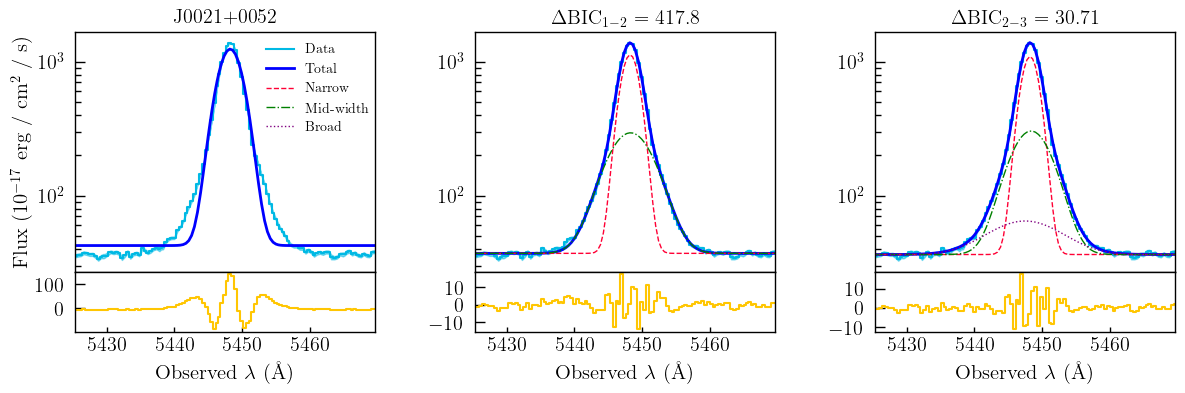

In [126]:
texPlot('on')

fig = plt.figure()
fig.set_size_inches(10, 3)

ax00 = fig.add_axes((0, .2, .3, .8))
ax10 = fig.add_axes((0, 0, .3, .2))

ax01 = fig.add_axes((.4, .2, .3, .8))
ax11 = fig.add_axes((.4, 0, .3, .2))

ax02 = fig.add_axes((.8, .2, .3, .8))
ax12 = fig.add_axes((.8, 0, .3, .2))

ax00.set_ylabel(r'Flux (10$^{-17}$ erg / cm$^{2}$ / s)', fontsize=15)
ax10.set_xlabel(r'Observed $\lambda$ (\AA)', fontsize=15)
ax11.set_xlabel(r'Observed $\lambda$ (\AA)', fontsize=15)
ax12.set_xlabel(r'Observed $\lambda$ (\AA)', fontsize=15)

ax00.set_xticks([])
ax01.set_xticks([])
ax02.set_xticks([])

ax00.tick_params(axis='y', direction='in', which='both')
ax01.tick_params(axis='y', direction='in', which='both')
ax02.tick_params(axis='y', direction='in', which='both')

ax10.tick_params(axis='both', direction='in', which='both')
ax11.tick_params(axis='both', direction='in', which='both')
ax12.tick_params(axis='both', direction='in', which='both')

ax00.set_yscale('log')
ax01.set_yscale('log')
ax02.set_yscale('log')

# Single component
oiiib_flux = out_oiii_4959.flatchain.Oiiib_flux.mean()
oiiib_std = out_oiii_4959.flatchain.Oiiib_flux.std()

bkg_oiii_4959 = out_oiii_4959.flatchain.bkg.mean()
z_oiii_4959 = out_oiii_4959.flatchain.z.mean()
sigma_oiii_4959 = out_oiii_4959.flatchain.sigma.mean()

oiiib_single = gaussian(oiii_4959.wavelength, oiiib_flux, wave_cat['[OIII]4959'], z_oiii_4959, sigma_oiii_4959)

ax00.step(oiii_4959.wavelength, oiii_4959.flux,
            color=c[0], label='Data', where='mid')
ax00.fill_between(oiii_4959.wavelength, oiii_4959.flux - oiii_4959.noise,
                                        oiii_4959.flux + oiii_4959.noise,
                 color=c[0], alpha=0.5)

ax00.plot(oiii_4959.wavelength, bkg_oiii_4959 + oiiib_single,
        lw=2, color='Blue', label='Best-fit')
ax10.step(oiii_4959.wavelength, oiii_4959.flux - bkg_oiii_4959 - oiiib_single,
         color=c[3], where='mid')

# Double component

oiiib2_nar_flux = out2_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib2_nar_std = out2_oiii_4959.flatchain.Oiiib_nar.std()

oiiib2_brd_flux = out2_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib2_brd_std = out2_oiii_4959.flatchain.Oiiib_brd.std()

bkg2_oiii_4959 = out2_oiii_4959.flatchain.bkg.mean()

z2_nar_oiii_4959 = out2_oiii_4959.flatchain.z_nar.mean()
z2_brd_oiii_4959 = out2_oiii_4959.flatchain.z_brd.mean()

sigma2_nar_oiii_4959 = out2_oiii_4959.flatchain.sigma_nar.mean()
sigma2_brd_oiii_4959 = out2_oiii_4959.flatchain.sigma_brd.mean()

oiiib2_nar = gaussian(oiii_4959.wavelength, oiiib2_nar_flux, wave_cat['[OIII]4959'], z2_nar_oiii_4959, sigma2_nar_oiii_4959)
oiiib2_brd = gaussian(oiii_4959.wavelength, oiiib2_brd_flux, wave_cat['[OIII]4959'], z2_brd_oiii_4959, sigma2_brd_oiii_4959)
oiiib2 = oiiib2_nar + oiiib2_brd

ax01.step(oiii_4959.wavelength, oiii_4959.flux,
            color=c[0], label='Data', where='mid')
ax01.fill_between(oiii_4959.wavelength, oiii_4959.flux - oiii_4959.noise,
                                        oiii_4959.flux + oiii_4959.noise,
                 color=c[0], alpha=0.5)
ax01.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib2,
        lw=2, color='blue', label='Best-fit')
ax01.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib2_nar, ls='--', lw=1, color=c[1])
ax01.plot(oiii_4959.wavelength, bkg2_oiii_4959 + oiiib2_brd, ls='-.', lw=1, color='green')
ax11.step(oiii_4959.wavelength, oiii_4959.flux - bkg2_oiii_4959 - oiiib2,
         color=c[3], where='mid')

# Triple component

oiiib3_nar_flux = out3_oiii_4959.flatchain.Oiiib_nar.mean()
oiiib3_nar_std = out3_oiii_4959.flatchain.Oiiib_nar.std()

oiiib3_mid_flux = out3_oiii_4959.flatchain.Oiiib_mid.mean()
oiiib3_mid_std = out3_oiii_4959.flatchain.Oiiib_mid.std()

oiiib3_brd_flux = out3_oiii_4959.flatchain.Oiiib_brd.mean()
oiiib3_brd_std = out3_oiii_4959.flatchain.Oiiib_brd.std()

bkg3_oiii_4959 = out3_oiii_4959.flatchain.bkg.mean()

z3_nar_oiii_4959 = out3_oiii_4959.flatchain.z_nar.mean()
z3_mid_oiii_4959 = out3_oiii_4959.flatchain.z_mid.mean()
z3_brd_oiii_4959 = out3_oiii_4959.flatchain.z_brd.mean()

sigma3_nar_oiii_4959 = out3_oiii_4959.flatchain.sigma_nar.mean()
sigma3_mid_oiii_4959 = out3_oiii_4959.flatchain.sigma_mid.mean()
sigma3_brd_oiii_4959 = out3_oiii_4959.flatchain.sigma_brd.mean()

oiiib3_nar = gaussian(oiii_4959.wavelength, oiiib3_nar_flux, wave_cat['[OIII]4959'], z3_nar_oiii_4959, sigma3_nar_oiii_4959)
oiiib3_mid = gaussian(oiii_4959.wavelength, oiiib3_mid_flux, wave_cat['[OIII]4959'], z3_mid_oiii_4959, sigma3_mid_oiii_4959)
oiiib3_brd = gaussian(oiii_4959.wavelength, oiiib3_brd_flux, wave_cat['[OIII]4959'], z3_brd_oiii_4959, sigma3_brd_oiii_4959)
oiiib3 = oiiib3_nar + oiiib3_mid + oiiib3_brd

ax02.step(oiii_4959.wavelength, oiii_4959.flux,
            color=c[0], label='Data', where='mid')
ax02.fill_between(oiii_4959.wavelength, oiii_4959.flux - oiii_4959.noise,
                                        oiii_4959.flux + oiii_4959.noise,
                 color=c[0], alpha=0.5)

ax02.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib3,
        lw=2, color='blue', label='Total')
ax02.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib3_nar, ls='--', lw=1, color=c[1], label='Narrow')
ax02.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib3_mid, ls='-.', lw=1, color='green', label='Mid-width')
ax02.plot(oiii_4959.wavelength, bkg3_oiii_4959 + oiiib3_brd, ls=':', lw=1, color='purple', label='Broad')
ax12.step(oiii_4959.wavelength, oiii_4959.flux - bkg3_oiii_4959 - oiiib3,
         color=c[3], where='mid')
ax02.legend(fontsize=10, loc=(-2.05, 0.55))

ax00.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax01.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax02.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax10.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax11.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))
ax12.set_xlim(np.min(oiii_4959.wavelength), np.max(oiii_4959.wavelength))

ax00.set_title('J0021+0052')
ax01.set_title(r'$\Delta$BIC$_{1-2}$'+' = {:.7}'.format(round(out_oiii_4959.bic - out2_oiii_4959.bic, 2)))
ax02.set_title(r'$\Delta$BIC$_{2-3}$'+' = {:.7}'.format(round(out2_oiii_4959.bic - out3_oiii_4959.bic, 2)))
#fig.savefig(magePath+'imges/comp_test/J0021.pdf', bbox_inches='tight');

In [127]:
bic_dict = {'galname': galname,
            'BIC_1_2': out_oiii_4959.bic - out2_oiii_4959.bic,
            'BIC_2_3': out2_oiii_4959.bic - out3_oiii_4959.bic
}
bic_dict_pd = pd.DataFrame(data=bic_dict, index=[0])
save_catalog(galname, bic_dict_pd, magePath + '/results/comp_test.csv')

File does not exist, creating new catalog...
Done.


---

In [51]:
from astropy.io import fits
spec2d = fits.open('/home/benjamin/Documents/pypeit18/redux_J0021/blue/magellan_mage_A/Science_coadd/spec2d_mage0083-mage0085-J0021+0052.fits')

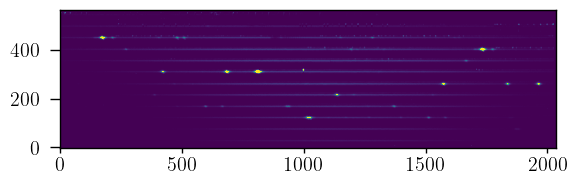

In [87]:
plt.imshow(np.transpose(spec2d[1].data), origin='lower', vmin=0, vmax=1000)

In [100]:
data_masked = np.ma.masked_where(np.logical_not((spec2d[8].data < 5470) & (spec2d[8].data > 5425)), spec2d[1].data)

In [101]:
mask_oiii = (spec2d[8].data < 5470) & (spec2d[8].data > 5425)

(298.0, 324.0)

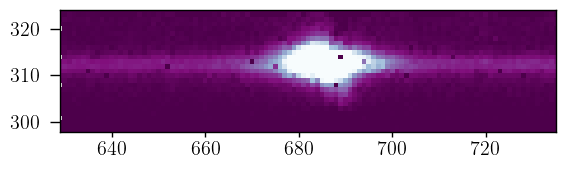

In [128]:
plt.imshow(np.transpose(data_masked), origin='lower', vmin=0, vmax=1000, cmap='BuPu_r')
plt.xlim(629, 735)
plt.ylim(298, 324)